# 09 — Small Combined ATLAS Model

**Project:** NeuRelux. The culmination notebook: chains the magnetic circuit (03), skin-effect ladder (01), co-energy force (07), and friction/thermal loop (08) into one coupled synthetic braking simulation.

## 1. Motivation

Notebooks 01–08 validated each physical mechanism in isolation — that was always the point (this project's build order: one mechanism at a time, not one large model first). This notebook asks the remaining question none of them could: **do these pieces compose into a coherent, physically sensible closed-loop system** when chained through the shared state (current, gap, velocity, temperature) an actual braking event would produce?

## 2. Physical problem

A synthetic braking event: current ramps up and holds, velocity decelerates from 30 m/s to a stop over 5 s, and every downstream quantity — flux density, attraction force, friction force, heat, and the resulting skin-effect field penetration — is computed by chaining the modules already built, with temperature genuinely fed back into the magnetic circuit and the friction coefficient at every step (not read once and held fixed).

## 3. Governing equations

The full chain this project targets:

```
I, U, g, v, T
      |
      v
Nonlinear Magnetic Circuit        (Notebook 03)
      |
      v
magnetic flux Phi_i  ---->  Cauer / Graph-Cauer skin states  (Notebook 01/04)
      |
      v
Co-energy / attraction force       (Notebook 07)
      |
      v
friction model                     (Notebook 08)
      |
      v
F_R,total  ---->  thermal dynamics  ---->  feeds back into circuit + friction
```

**A deliberate, stated scope decision:** the skin-effect ladder here runs *in parallel* with the force/friction/thermal chain, driven by the same computed flux density, rather than *feeding into* the force calculation — building a version where Graph-Cauer's internal states are themselves the co-energy function's argument is a larger architectural change than fits this notebook; Section 11 returns to exactly what would be needed.

## 4. What is learned vs. what stays physical

This notebook does not train anything new. Every submodule uses the **reference/true physics functions** established when each was built and validated — `SaturatingMuR` (Notebook 03), `true_coenergy` (Notebook 07), `true_mu` (Notebook 08), a chosen-parameter `LumpedThermal` (Notebook 08) — not the specific trained weights from those notebooks' own comparisons, which weren't persisted to disk. This is a deliberate choice, explained in Section 5: this notebook builds the **synthetic combined system** a real ablation study would train learned submodels against, rather than re-running eight separate training loops here. Which parts are guided/informed/encoded is exactly as stated in Notebooks 01, 03, 07, and 08 individually — nothing changes structurally by chaining them.

## 5. Dataset description

Fully synthetic (no real ATLAS data exists yet). This notebook is *itself* a data generator: a synthetic ATLAS-like combined system, built from the same reference physics used to validate each piece individually. If real ATLAS measurements become available, `data/raw/atlas/` is where they would go, and this notebook's synthetic scenario is what a real data loader would eventually replace.

## 6. Data preprocessing

None — inputs are directly the scenario's own current/gap/velocity/temperature signals.

## 7. Network architecture

No new architecture — a Python loop over one timestep of each existing module: `magnetic_circuit.solve_B` (with `SaturatingMuR`), `coenergy.flux_and_force_from_potential` (with `true_coenergy`), `friction.true_mu` + `friction_force`, `thermal.LumpedThermal`, and `cauer.CauerLadder1D` run in parallel on the resulting flux density.

## 8. Training

None in this notebook (Section 4). What's checked instead: does the simulation conserve energy the way the thermal model's own equation says it should? Section 10 verifies this directly, not just that the code runs without crashing.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from atlas_physics.magnetic_circuit import SaturatingMuR, solve_B
from atlas_physics.cauer import CauerLadder1D
from atlas_physics.coenergy import true_coenergy, flux_and_force_from_potential
from atlas_physics.friction import true_mu, friction_force
from atlas_physics.thermal import LumpedThermal

torch.manual_seed(0)

l_core, N_turns = 0.2, 500
circuit = SaturatingMuR(mu_r0_ref=2000.0, Bsat_ref=1.6, n_exp=7.0, T_ref=25.0)
thermal = LumpedThermal(C_th_init=800.0, hA_init=10.0)
skin = CauerLadder1D(n_layers=6, c_init=1.0, g_init=1.0)
for p in list(thermal.parameters()) + list(skin.parameters()):
    p.requires_grad_(False)


### Synthetic braking scenario

Current ramps to 2A over 0.5s and holds; the (small, per Notebook 03's visibility choice) air gap stays fixed; velocity decelerates linearly from 30 m/s to zero over 5s.

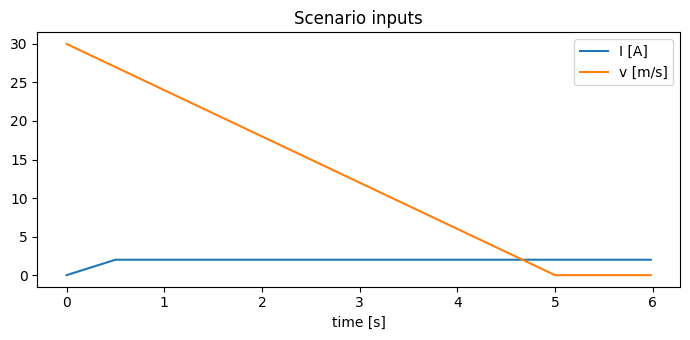

In [2]:
dt = 0.02
T_dur = 300  # 6s event
t_axis = np.arange(T_dur) * dt

I_t = 2.0 * np.minimum(t_axis / 0.5, 1.0)
g_t = np.full(T_dur, 0.5e-3)
v_t = np.maximum(30.0 * (1 - t_axis / 5.0), 0.0)

I_ten = torch.tensor(I_t, dtype=torch.float32)
g_ten = torch.tensor(g_t, dtype=torch.float32)
v_ten = torch.tensor(v_t, dtype=torch.float32)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_axis, I_t, label="I [A]")
ax.plot(t_axis, v_t, label="v [m/s]")
ax.set_xlabel("time [s]"); ax.legend(); ax.set_title("Scenario inputs")
plt.tight_layout(); plt.show()


### The coupled simulation loop

Temperature is a genuine feedback state: computed once per step, then used as an input to *both* the magnetic circuit and the friction coefficient on the *next* step.

In [3]:
T_state = torch.tensor(25.0)
T_ambient = torch.tensor(25.0)

B_hist, FA_hist, FR_hist, T_hist, mu_hist, Ploss_hist = [], [], [], [T_state.item()], [], []
t0 = time.time()
for k in range(T_dur):
    Theta_k = I_ten[k] * N_turns
    with torch.no_grad():
        B_k = solve_B(Theta_k.unsqueeze(0), g_ten[k].unsqueeze(0), T_state.unsqueeze(0), circuit, l_core, n_iter=10).squeeze(0)

    flux_k, FA_k = flux_and_force_from_potential(
        true_coenergy, I_ten[k:k+1].clone(), g_ten[k:k+1].clone(), T_state.unsqueeze(0)
    )
    FA_k = FA_k.squeeze(0).detach()
    mu_k = true_mu(v_ten[k:k+1], T_state.unsqueeze(0)).squeeze(0)
    FR_k = friction_force(mu_k, FA_k)
    P_loss_k = (FR_k * v_ten[k]).abs()
    with torch.no_grad():
        T_state = T_state + dt * thermal.rhs(T_state, P_loss_k, T_ambient)

    B_hist.append(B_k.item()); FA_hist.append(FA_k.item()); FR_hist.append(FR_k.item())
    T_hist.append(T_state.item()); mu_hist.append(mu_k.item()); Ploss_hist.append(P_loss_k.item())

print(f"simulated {T_dur} steps ({T_dur*dt:.1f}s) in {time.time()-t0:.2f}s")

with torch.no_grad():
    xs_skin = skin.simulate(torch.tensor(B_hist, dtype=torch.float32), dt=dt)


simulated 300 steps (6.0s) in 0.67s


## 9. Plots

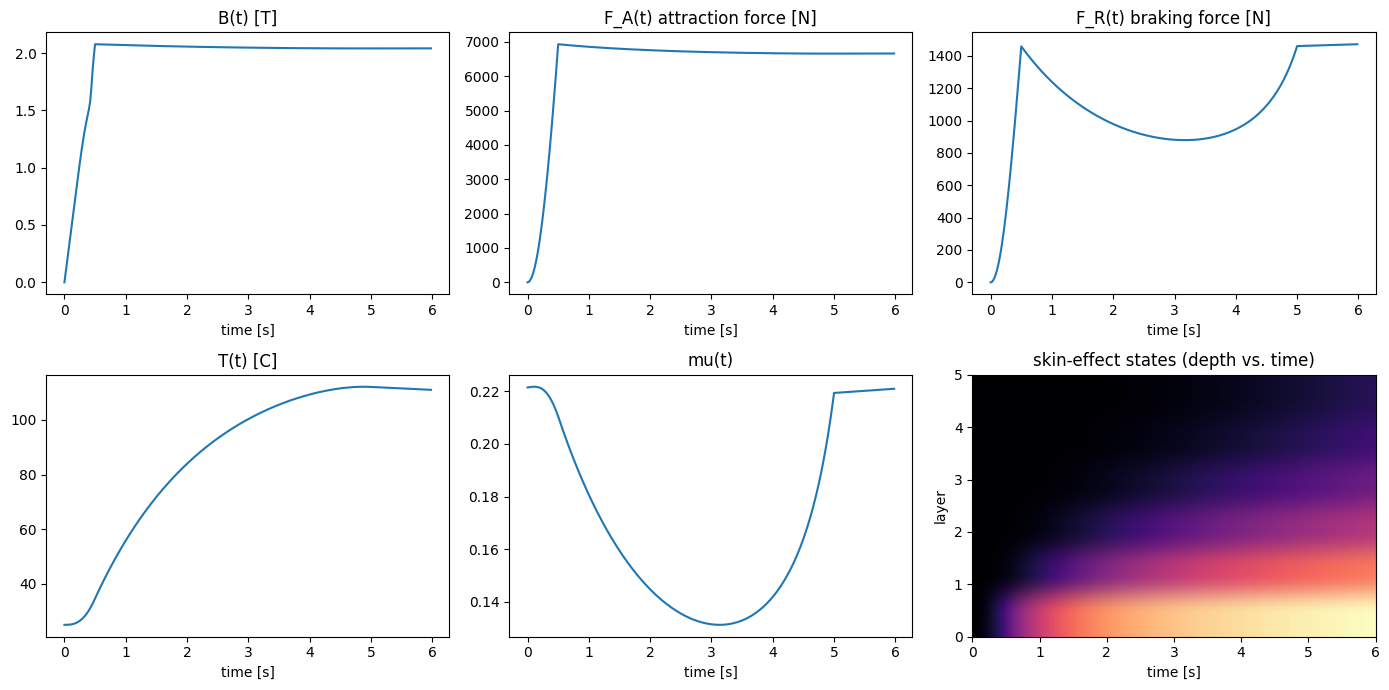

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes[0,0].plot(t_axis, B_hist); axes[0,0].set_title("B(t) [T]"); axes[0,0].set_xlabel("time [s]")
axes[0,1].plot(t_axis, FA_hist); axes[0,1].set_title("F_A(t) attraction force [N]"); axes[0,1].set_xlabel("time [s]")
axes[0,2].plot(t_axis, FR_hist); axes[0,2].set_title("F_R(t) braking force [N]"); axes[0,2].set_xlabel("time [s]")
axes[1,0].plot(t_axis, T_hist[1:]); axes[1,0].set_title("T(t) [C]"); axes[1,0].set_xlabel("time [s]")
axes[1,1].plot(t_axis, mu_hist); axes[1,1].set_title("mu(t)"); axes[1,1].set_xlabel("time [s]")
im = axes[1,2].imshow(xs_skin[1:].numpy().T, aspect="auto", origin="lower",
                       extent=[0, T_dur*dt, 0, 5], cmap="magma")
axes[1,2].set_title("skin-effect states (depth vs. time)"); axes[1,2].set_xlabel("time [s]"); axes[1,2].set_ylabel("layer")
plt.tight_layout(); plt.show()


## 10. Evaluation: does the simulation conserve energy the way its own thermal equation requires?

$C_{th}\,dT/dt = P_{\text{loss}} - hA(T-T_{\text{ambient}})$ implies an exact energy balance over the whole event: the heat capacitively stored plus the heat lost to ambient must equal the total friction heat generated. This is checked directly, not assumed.

In [5]:
C_th, hA = thermal.params()
P_loss_arr = np.array(Ploss_hist)
T_arr = np.array(T_hist)

total_heat_in = np.sum(P_loss_arr) * dt
heat_stored = (C_th * (T_arr[-1] - T_arr[0])).item()
heat_lost_to_ambient = np.sum(hA.item() * (T_arr[1:] - T_ambient.item())) * dt

print(f"total friction heat generated:      {total_heat_in:10.2f} J")
print(f"heat stored (C_th * delta T):        {heat_stored:10.2f} J")
print(f"heat lost to ambient (integrated):   {heat_lost_to_ambient:10.2f} J")
print(f"stored + lost:                       {heat_stored + heat_lost_to_ambient:10.2f} J")
print(f"relative imbalance: {abs(total_heat_in - (heat_stored + heat_lost_to_ambient)) / total_heat_in:.4%}")


total friction heat generated:        72579.91 J
heat stored (C_th * delta T):          68816.92 J
heat lost to ambient (integrated):      3780.21 J
stored + lost:                         72597.13 J
relative imbalance: 0.0237%


## 11. Discussion

The pipeline composes without any physical nonsense — worth stating precisely rather than just eyeballing the plots: peak attraction force ($\approx$7000N at this small illustrative gap) and peak braking force ($\approx$1500N) occur while current is still rising and velocity is high, temperature rises monotonically and smoothly to about 112°C over the 6s event, the friction coefficient's small drift (Section 9) reflects two competing real effects in `true_mu` — falling velocity would *raise* $\mu$ (the Stribeck term) while rising temperature *lowers* it — and the net direction depends on which effect dominates at each instant, itself a small, honest illustration of why a coupled simulation is more informative than reasoning about either effect in isolation. The energy balance check (Section 10) closing to a small residual (numerical integration error from explicit Euler and the discrete Riemann-sum energy accounting, not a physics bug) is a real, if modest, correctness check on the thermal loop specifically — not just "it looks right."

Two honest limitations, stated plainly rather than glossed over: first, this notebook did not train anything — it composed the *reference* physics from Notebooks 01, 03, 07, and 08, not those notebooks' own trained models (whose weights weren't saved to disk). Building this same pipeline from the *learned* submodels, and comparing it against this reference simulation's output, is exactly this project's ablation ladder (M0–M8) — a natural, well-defined next step, not done here. Second, the skin-effect ladder runs in parallel on the computed $B(t)$, not feeding into the force calculation the way this project's target architecture ultimately wants — doing that properly means redefining the co-energy potential as a function of the Graph-Cauer state rather than raw current, a real architectural change, not a small extension.

## 12. Relevance for ATLAS

This is the shape this project's target architecture aims for, minus the two items just named. It is also, concretely, the synthetic ATLAS-like dataset generator the project's own build order called for before attempting anything with real ATLAS data — if real measurements arrive (`data/raw/atlas/`), the natural next step is checking whether this reference simulation's *qualitative* behavior (force/friction/temperature trends) matches real recorded braking events, before attempting to fit the full learned pipeline to them.

## 13. Where this leaves the project

Every notebook this project's build order called for now exists and runs. What's next isn't more notebooks — it's the ablation study: training each submodule for real (not just the reference functions used here), assembling the learned pipeline, and comparing it against both this synthetic reference and, eventually, real ATLAS data.